# Bernoulli Coin-Flip Toy Notebook

This notebook uses one simple Bernoulli coin-flip example to teach four core ideas:

1. Monte Carlo simulation
2. Law of Large Numbers (LLN)
3. Central Limit Theorem (CLT)
4. Common Random Numbers (CRN)

The setup stays the same throughout:

- $X \sim \mathrm{Bernoulli}(p)$ with $p = 0.3$
- one replication = one random outcome $X_i \in \{0,1\}$
- the main quantity of interest is $\mathbb{E}[X] = p$
- later we compare two simple policies on the same Bernoulli worlds

The goal is not clever code. The goal is to make the statistical ideas visually and mathematically transparent.

## Section 1 - Problem setup

A Bernoulli random variable takes only two values:

- $X = 1$ with probability $p$
- $X = 0$ with probability $1-p$

You can read $X$ in many ways:

- success / failure
- stockout / no stockout
- customer buys / does not buy
- machine fails / does not fail

Here we set $p = 0.3$, so the event $X=1$ happens about 30 percent of the time.

The true expected value is

$$\mathbb{E}[X] = p = 0.3$$


For the CRN sections, we also define two simple cost rules:

$$
c_A(X) = \begin{cases}
10, & X=1 \\
2, & X=0
\end{cases}
\qquad
c_B(X) = \begin{cases}
7, & X=1 \\
3, & X=0.
\end{cases}
$$

So policy B is cheaper when failure happens, but slightly more expensive when failure does not happen.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')

SEED = 20260410
P = 0.30


def simulate_bernoulli(p, n, rng):
    """Simulate n Bernoulli(p) trials."""
    return rng.binomial(1, p, size=n)


def monte_carlo_estimate(samples):
    """Return the sample mean and its Monte Carlo standard error."""
    mean = samples.mean()
    se = samples.std(ddof=1) / np.sqrt(len(samples))
    return mean, se


def running_mean(samples):
    """Running average after each replication."""
    return np.cumsum(samples) / np.arange(1, len(samples) + 1)


def many_running_means(p, n, n_runs, seed):
    """Generate many independent running means for LLN plots."""
    rng = np.random.default_rng(seed)
    samples = rng.binomial(1, p, size=(n_runs, n))
    return samples.cumsum(axis=1) / np.arange(1, n + 1)


def repeated_sample_means(p, n, n_repeats, seed):
    """Generate many sample means for CLT histograms."""
    rng = np.random.default_rng(seed)
    samples = rng.binomial(1, p, size=(n_repeats, n))
    return samples.mean(axis=1)


def policy_costs(x):
    """Map Bernoulli outcomes to policy costs."""
    cost_a = np.where(x == 1, 10.0, 2.0)
    cost_b = np.where(x == 1, 7.0, 3.0)
    return cost_a, cost_b


def compare_independent(p, n, rng):
    """Estimate Delta using independent random samples for A and B."""
    x_a = simulate_bernoulli(p, n, rng)
    x_b = simulate_bernoulli(p, n, rng)
    cost_a, _ = policy_costs(x_a)
    _, cost_b = policy_costs(x_b)
    delta_hat = cost_a.mean() - cost_b.mean()
    se_hat = np.sqrt(cost_a.var(ddof=1) / n + cost_b.var(ddof=1) / n)
    return {
        'delta_hat': delta_hat,
        'se_hat': se_hat,
        'cost_a': cost_a,
        'cost_b': cost_b,
    }


def compare_crn(p, n, rng):
    """Estimate Delta using the same Bernoulli outcomes for both policies."""
    x = simulate_bernoulli(p, n, rng)
    cost_a, cost_b = policy_costs(x)
    paired_diff = cost_a - cost_b
    delta_hat = paired_diff.mean()
    se_hat = paired_diff.std(ddof=1) / np.sqrt(n)
    return {
        'delta_hat': delta_hat,
        'se_hat': se_hat,
        'paired_diff': paired_diff,
        'cost_a': cost_a,
        'cost_b': cost_b,
    }


def repeated_estimates(method, p, n, n_repeats, seed):
    """Repeat a comparison method many times."""
    rng = np.random.default_rng(seed)
    deltas = np.empty(n_repeats)
    ses = np.empty(n_repeats)
    for i in range(n_repeats):
        result = method(p, n, rng)
        deltas[i] = result['delta_hat']
        ses[i] = result['se_hat']
    return deltas, ses


def normal_pdf(x, mean, std):
    """Normal density for a CLT overlay."""
    z = (x - mean) / std
    return np.exp(-0.5 * z**2) / (std * np.sqrt(2.0 * np.pi))

In [2]:
# Problem parameters.
true_mean = P

# The two simple policy cost rules.
cost_a_if_1, cost_a_if_0 = 10.0, 2.0
cost_b_if_1, cost_b_if_0 = 7.0, 3.0

# True expected costs under the Bernoulli model.
expected_cost_a = P * cost_a_if_1 + (1.0 - P) * cost_a_if_0
expected_cost_b = P * cost_b_if_1 + (1.0 - P) * cost_b_if_0
true_delta = expected_cost_a - expected_cost_b

print(f'True Bernoulli mean E[X] = p = {true_mean:.3f}')
print(f'True expected cost of policy A = {expected_cost_a:.3f}')
print(f'True expected cost of policy B = {expected_cost_b:.3f}')
print(f'True cost gap Delta = E[c_A] - E[c_B] = {true_delta:.3f}')

True Bernoulli mean E[X] = p = 0.300
True expected cost of policy A = 4.400
True expected cost of policy B = 4.200
True cost gap Delta = E[c_A] - E[c_B] = 0.200


## Section 2 - Monte Carlo simulation

Monte Carlo simulation means: repeat a random experiment many times and average the outcomes.

For Bernoulli data, the natural Monte Carlo estimator of $p$ is the sample average:

$$\hat p_N = \frac{1}{N} \sum_{i=1}^N X_i.$$

Because $X_i$ is either 0 or 1, this sample average is also the sample proportion of ones.

We will simulate many Bernoulli replications, estimate $p$, and then inspect how the estimate behaves over time.

In [14]:
# One Monte Carlo run.
n_mc = 100000
samples = simulate_bernoulli(P, n_mc, np.random.default_rng(SEED + 1))
mc_estimate, mc_se = monte_carlo_estimate(samples)

print(f'Number of replications N = {n_mc}')
print(f'Monte Carlo estimate of p = {mc_estimate:.4f}')
print(f'Monte Carlo standard error = {mc_se:.4f}')
print(f'True value p = {true_mean:.4f}')
print(f'Absolute error = {abs(mc_estimate - true_mean):.4f}')

Number of replications N = 100000
Monte Carlo estimate of p = 0.2997
Monte Carlo standard error = 0.0014
True value p = 0.3000
Absolute error = 0.0003


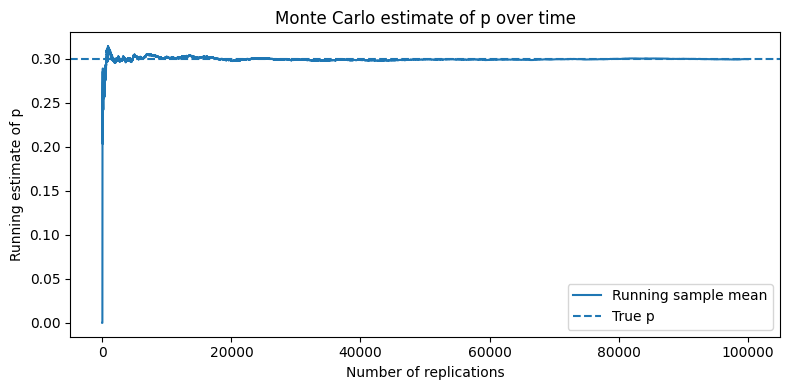

In [15]:
# Running sample mean: how the estimate evolves as replications accumulate.
plt.figure(figsize=(8, 4))
plt.plot(running_mean(samples), label='Running sample mean')
plt.axhline(true_mean, linestyle='--', label='True p')
plt.xlabel('Number of replications')
plt.ylabel('Running estimate of p')
plt.title('Monte Carlo estimate of p over time')
plt.legend()
plt.tight_layout()
plt.show()

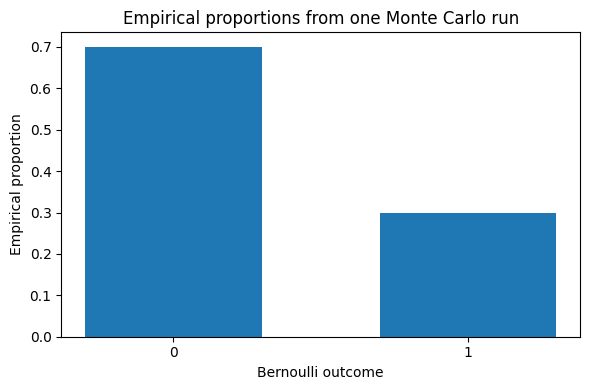

In [16]:
# Empirical proportions of 0 and 1 in the Monte Carlo sample.
values, counts = np.unique(samples, return_counts=True)
proportions = counts / n_mc

plt.figure(figsize=(6, 4))
plt.bar(values, proportions, width=0.6)
plt.xticks([0, 1], ['0', '1'])
plt.xlabel('Bernoulli outcome')
plt.ylabel('Empirical proportion')
plt.title('Empirical proportions from one Monte Carlo run')
plt.tight_layout()
plt.show()

## Section 3 - LLN visualization

The Law of Large Numbers says that the sample average stabilizes around the true expected value.

For Bernoulli data, this means:

$$\hat p_N = \frac{1}{N} \sum_{i=1}^N X_i \to p \quad \text{as } N \to \infty.$$

The key message is not that random noise disappears. The key message is that averaging many random replications makes the estimate more stable and closer to the truth.

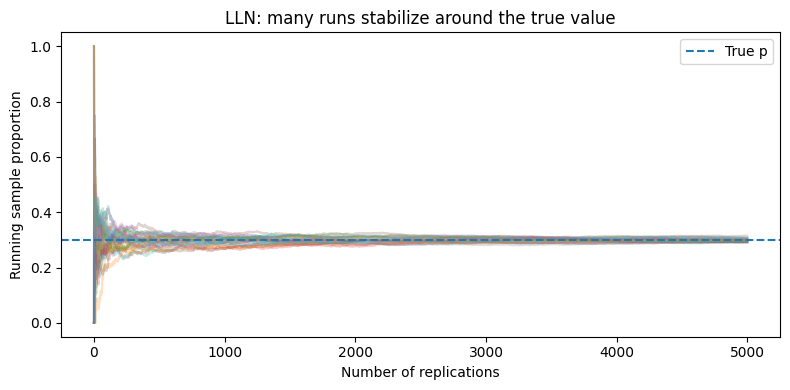

In [18]:
# Many independent Monte Carlo runs, each with its own running sample proportion.
n_lln = 5000
n_runs = 30
lln_paths = many_running_means(P, n_lln, n_runs, SEED + 2)

plt.figure(figsize=(8, 4))
for path in lln_paths:
    plt.plot(path, alpha=0.25)
plt.axhline(true_mean, linestyle='--', label='True p')
plt.xlabel('Number of replications')
plt.ylabel('Running sample proportion')
plt.title('LLN: many runs stabilize around the true value')
plt.legend()
plt.tight_layout()
plt.show()

## Section 4 - CLT visualization

The Central Limit Theorem says that the sample mean becomes approximately normal when the sample size is large.

For Bernoulli data, the standard CLT statement is:

$$\sqrt{N}(\hat p_N - p) \approx \mathcal{N}(0, p(1-p)),$$

or equivalently,

$$\hat p_N \approx \mathcal{N}\left(p, \frac{p(1-p)}{N}\right).$$

So LLN explains **why the average stabilizes**, while CLT explains **what the remaining estimation error looks like** for large $N$.

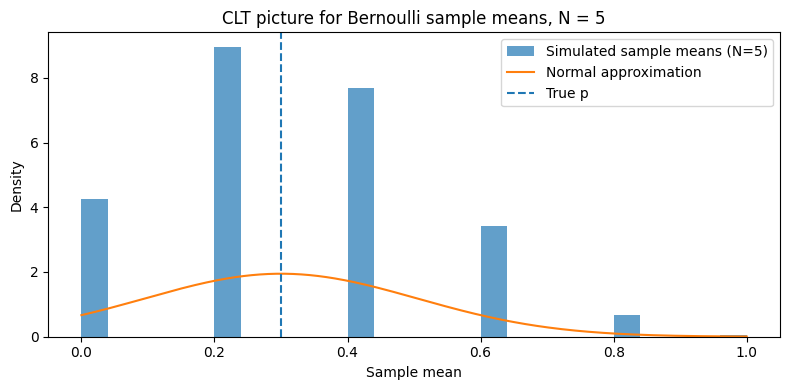

N =   5 | simulated mean of sample means = 0.2994 | simulated sd = 0.2043


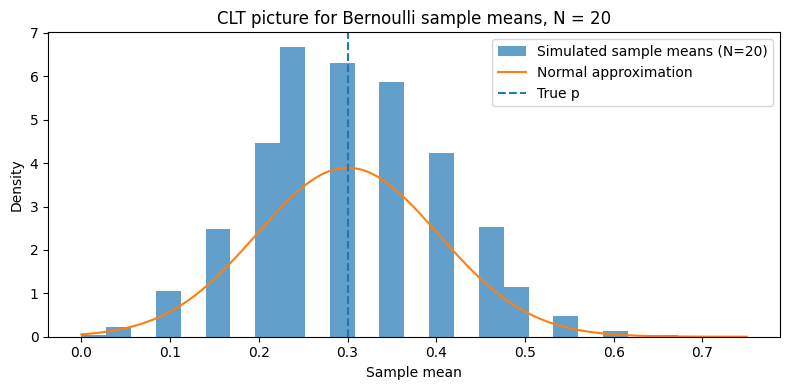

N =  20 | simulated mean of sample means = 0.3019 | simulated sd = 0.1040


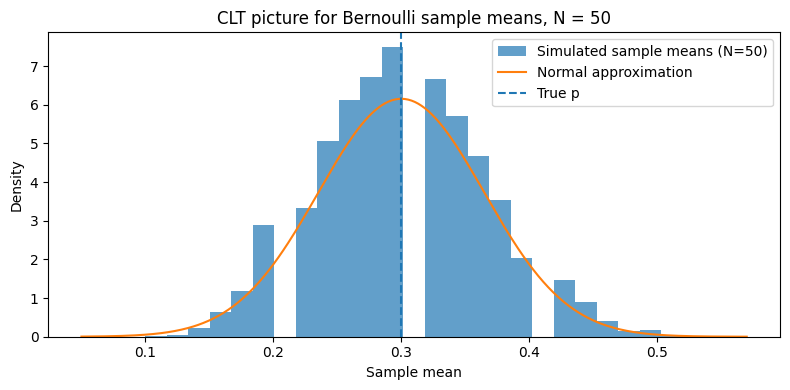

N =  50 | simulated mean of sample means = 0.3008 | simulated sd = 0.0652


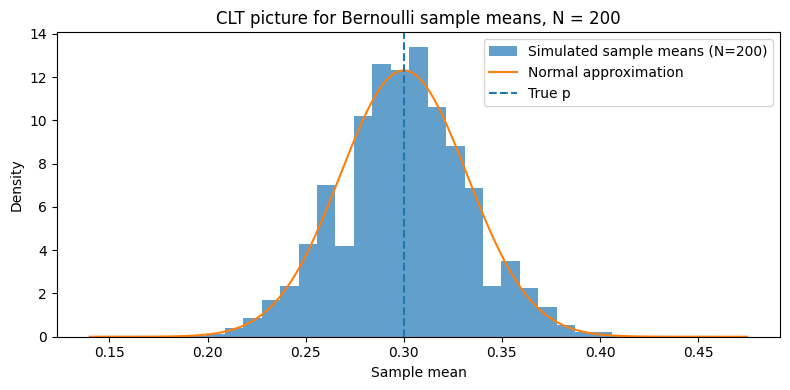

N = 200 | simulated mean of sample means = 0.3002 | simulated sd = 0.0328


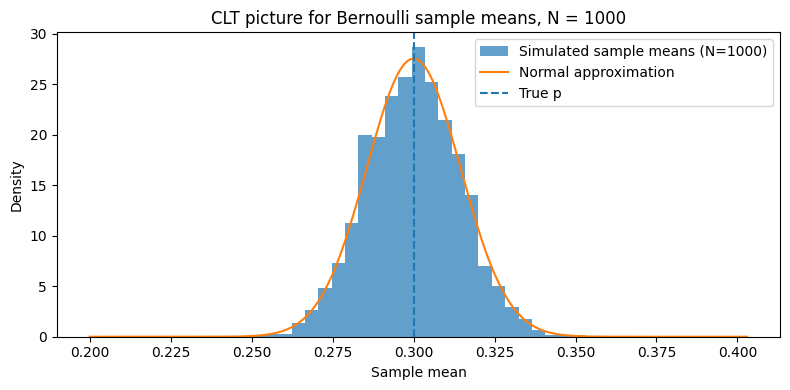

N = 1000 | simulated mean of sample means = 0.2998 | simulated sd = 0.0143


In [19]:
# Histograms of sample means for different sample sizes.
sample_sizes = [5, 20, 50, 200, 1000]
n_repeats_clt = 4000

for n in sample_sizes:
    means = repeated_sample_means(P, n, n_repeats_clt, SEED + n)
    approx_std = np.sqrt(P * (1.0 - P) / n)
    xs = np.linspace(max(0.0, means.min() - 0.05), min(1.0, means.max() + 0.05), 400)

    plt.figure(figsize=(8, 4))
    plt.hist(means, bins=25, density=True, alpha=0.7, label=f'Simulated sample means (N={n})')
    plt.plot(xs, normal_pdf(xs, P, approx_std), label='Normal approximation')
    plt.axvline(P, linestyle='--', label='True p')
    plt.xlabel('Sample mean')
    plt.ylabel('Density')
    plt.title(f'CLT picture for Bernoulli sample means, N = {n}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f'N = {n:3d} | simulated mean of sample means = {means.mean():.4f} | simulated sd = {means.std(ddof=1):.4f}')

## Section 5 - Policy comparison without CRN

Now we compare the two simple policies using their costs.

The true comparison target is

$$\Delta = \mathbb{E}[c_A(X)] - \mathbb{E}[c_B(X)].$$

Without CRN, we estimate this by simulating policy A on one random sample and policy B on a different random sample:

$\hat\Delta_{\mathrm{ind}} = \bar c_A - \bar c_B.$ 

This works, but it introduces extra comparison noise because the two policies are not being evaluated on the same random worlds.

In [8]:
# One independent policy comparison and then many repeated comparisons.
n_compare = 100
n_repeat_compare = 3000

independent_one = compare_independent(P, n_compare, np.random.default_rng(SEED + 20))
independent_deltas, independent_ses = repeated_estimates(
    compare_independent,
    P,
    n_compare,
    n_repeat_compare,
    SEED + 21,
)

print(f'One independent estimate of Delta = {independent_one["delta_hat"]:.4f}')
print(f'Estimated standard error in that run = {independent_one["se_hat"]:.4f}')
print(f'True Delta = {true_delta:.4f}')
print()
print(f'Across {n_repeat_compare} repeated comparisons:')
print(f'Average estimated Delta = {independent_deltas.mean():.4f}')
print(f'Sampling sd of the independent estimator = {independent_deltas.std(ddof=1):.4f}')
print(f'Average reported standard error = {independent_ses.mean():.4f}')

One independent estimate of Delta = 0.0000
Estimated standard error in that run = 0.4009
True Delta = 0.2000

Across 3000 repeated comparisons:
Average estimated Delta = 0.2107
Sampling sd of the independent estimator = 0.4024
Average reported standard error = 0.4097


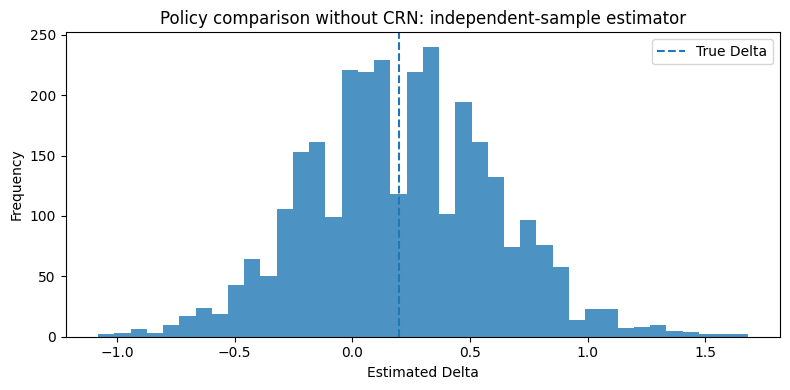

In [9]:
# Sampling distribution of the independent-comparison estimator.
plt.figure(figsize=(8, 4))
plt.hist(independent_deltas, bins=40, alpha=0.8)
plt.axvline(true_delta, linestyle='--', label='True Delta')
plt.xlabel('Estimated Delta')
plt.ylabel('Frequency')
plt.title('Policy comparison without CRN: independent-sample estimator')
plt.legend()
plt.tight_layout()
plt.show()

## Section 6 - Policy comparison with CRN

With Common Random Numbers, both policies are evaluated on the **same Bernoulli outcomes** $X_1, \ldots, X_N$.

We then form paired differences:

$$D_i = c_A(X_i) - c_B(X_i),$$

and estimate the cost gap by

$$\hat\Delta_{\mathrm{CRN}}=\frac{1}{N}\sum_{i=1}^N(D_i)$$

The teaching slogan is:

**Pair first, average second.**

CRN does not change the true expected cost gap. It changes how noisy the estimator is.

In [10]:
# One CRN comparison and then many repeated CRN comparisons.
crn_one = compare_crn(P, n_compare, np.random.default_rng(SEED + 22))
crn_deltas, crn_ses = repeated_estimates(
    compare_crn,
    P,
    n_compare,
    n_repeat_compare,
    SEED + 23,
)

ind_var = independent_deltas.var(ddof=1)
crn_var = crn_deltas.var(ddof=1)
variance_reduction_factor = ind_var / crn_var

print(f'One CRN estimate of Delta = {crn_one["delta_hat"]:.4f}')
print(f'Estimated standard error in that run = {crn_one["se_hat"]:.4f}')
print(f'First 10 paired differences D_i = {crn_one["paired_diff"][:10]}')
print()
print(f'Across {n_repeat_compare} repeated comparisons:')
print(f'Average estimated Delta = {crn_deltas.mean():.4f}')
print(f'Sampling sd of the CRN estimator = {crn_deltas.std(ddof=1):.4f}')
print(f'Average reported standard error = {crn_ses.mean():.4f}')
print()
print(f'Variance of independent estimator = {ind_var:.6f}')
print(f'Variance of CRN estimator = {crn_var:.6f}')
print(f'Empirical variance reduction factor = {variance_reduction_factor:.3f}x')

assert crn_var < ind_var, 'In this example CRN should reduce variance.'
print('Sanity check passed: CRN variance is smaller than independent variance.')

One CRN estimate of Delta = 0.1600
Estimated standard error in that run = 0.1824
First 10 paired differences D_i = [ 3. -1. -1. -1. -1.  3. -1. -1. -1.  3.]

Across 3000 repeated comparisons:
Average estimated Delta = 0.1987
Sampling sd of the CRN estimator = 0.1847
Average reported standard error = 0.1830

Variance of independent estimator = 0.161906
Variance of CRN estimator = 0.034104
Empirical variance reduction factor = 4.747x
Sanity check passed: CRN variance is smaller than independent variance.


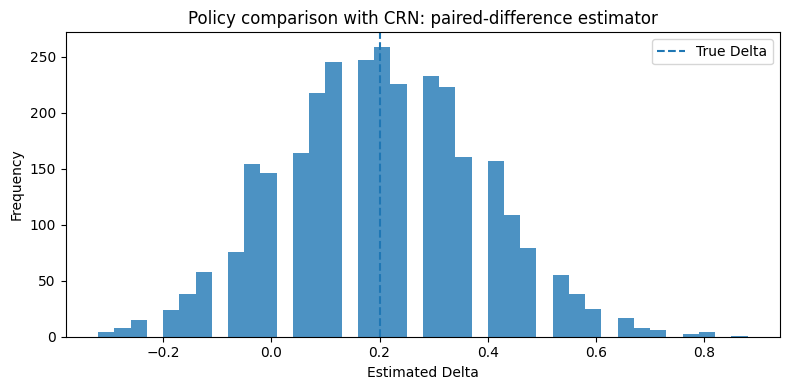

In [11]:
# Sampling distribution of the CRN-based estimator.
plt.figure(figsize=(8, 4))
plt.hist(crn_deltas, bins=40, alpha=0.8)
plt.axvline(true_delta, linestyle='--', label='True Delta')
plt.xlabel('Estimated Delta')
plt.ylabel('Frequency')
plt.title('Policy comparison with CRN: paired-difference estimator')
plt.legend()
plt.tight_layout()
plt.show()

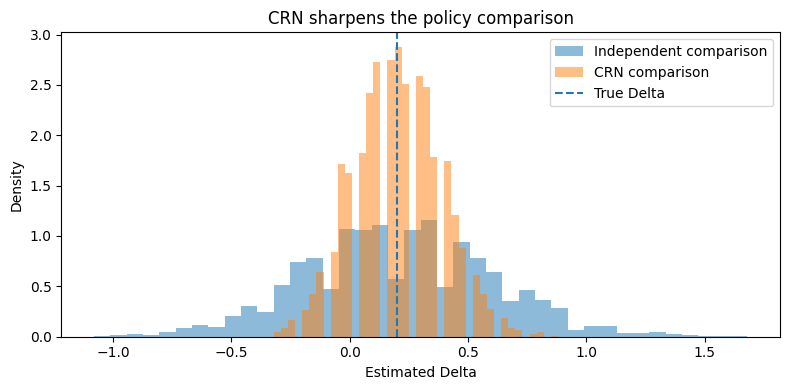

In [12]:
# Direct visual comparison of independent versus CRN estimators.
plt.figure(figsize=(8, 4))
plt.hist(independent_deltas, bins=40, density=True, alpha=0.5, label='Independent comparison')
plt.hist(crn_deltas, bins=40, density=True, alpha=0.5, label='CRN comparison')
plt.axvline(true_delta, linestyle='--', label='True Delta')
plt.xlabel('Estimated Delta')
plt.ylabel('Density')
plt.title('CRN sharpens the policy comparison')
plt.legend()
plt.tight_layout()
plt.show()

## Section 7 - Connect the ideas

| Concept | Main idea | What it explains in this notebook |
|---|---|---|
| Monte Carlo | Average over random replications | Why the sample mean is our estimator of $p$ |
| LLN | The average stabilizes around the truth | Why running sample proportions settle near $p$ |
| CLT | The estimation error becomes approximately normal | Why sample means have a bell-shaped sampling distribution for large $N$ |
| CRN | Share the same random worlds across alternatives | Why paired policy comparisons have less variance |

This is the conceptual ladder:

- Monte Carlo gives us the estimator.
- LLN explains convergence.
- CLT explains remaining uncertainty.
- CRN improves comparisons by removing unnecessary comparison noise.

## Section 8 - Final takeaway

- One Bernoulli trial is one possible world.
- Many Bernoulli trials let us estimate the expected value $\mathbb{E}[X] = p$.
- The Law of Large Numbers explains why the average stabilizes.
- The Central Limit Theorem explains how the estimation error is distributed for large samples.
- Common Random Numbers sharpen comparisons by evaluating alternatives on the same random worlds.

If students keep one mental picture, it should be this:

**simulate, average, stabilize, approximate, then pair to compare better.**

## Final teaching notes

### Likely student misunderstandings

- **Monte Carlo versus LLN:** students may think they are the same thing. Emphasize that Monte Carlo is the computational procedure, while LLN is the convergence explanation.
- **LLN versus CLT:** students may think both say 'the estimator becomes correct.' Emphasize that LLN is about stabilization, while CLT is about the distribution of the remaining error.
- **CRN:** students may think CRN changes the true answer. Emphasize that CRN changes the variance of the comparison, not the expected cost gap itself.
- **Likelihood versus probability:** if you verbally connect this notebook to later inference topics, remind students that a model can produce probabilities for data without yet producing a posterior over parameters.

### What each plot is intended to teach

- **Running mean plot:** one Monte Carlo estimate is noisy early and stabilizes later.
- **Empirical proportion plot:** Bernoulli data are extremely simple, but the sample still reflects randomness.
- **LLN multi-run plot:** many independent runs all settle near the truth, even though they wiggle differently.
- **CLT histograms:** sample means become more bell-shaped and tighter as $N$ grows.
- **Independent-comparison histogram:** policy comparison can be noisy when each alternative sees different random worlds.
- **CRN histogram and overlay:** pairing the alternatives reduces spread and makes the comparison sharper.

### What the lecturer should verbally emphasize

- 'One trial is one possible world.'
- 'Monte Carlo means average over many worlds.'
- 'LLN explains why the average settles down.'
- 'CLT explains what the remaining uncertainty looks like.'
- 'CRN means compare alternatives on the same worlds.'
- 'Pair first, average second.'

### One short lecture-ready summary

This Bernoulli toy example is deliberately simple so that the concepts do not hide behind complicated system dynamics. If students understand Monte Carlo, LLN, CLT, and CRN here, they are much better prepared to recognize the same ideas in larger SDAM simulations.